In [24]:
library(here)
library(pheatmap)
library(corrplot)

library(MASS)
library(pROC)
library(glmnet)

### Problem 1

### a)

We know that,
$$\hat{B}_{OLS} = (X^TX)^{-1}X^TY$$
$$\implies X^TY = (X^TX)\hat{B}_{OLS} \tag{1}$$

Consider,
$$\lVert Y-XB \rVert_F^2 = (Y-XB)^T(Y-XB)$$
$$ = (Y^T-B^TX^T)(Y-XB) $$
$$ = Y^TY-B^TX^TY -Y^TXB +B^TX^TXB $$

Note,
$$ B^TX^TY = Y^TXB \in \mathbb{R}^{1\text{x}1} $$

Therefore,
$$\lVert Y-XB \rVert_F^2 = Y^TY-2B^TX^TY +B^TX^TXB $$
$$ = Y^TY-2B^TX^TX\hat{B}_{OLS} +B^TX^TXB \tag{2} $$


Now,
$$\lVert Y-XB \rVert_F^2 - \lVert Y-X\hat{B}_{OLS} \rVert_F^2$$
$$ = B^TX^TXB - 2B^TX^TX\hat{B}_{OLS} + \hat{B}_{OLS}^TX^TX\hat{B}_{OLS} $$
$$ = \lVert X\hat{B}_{OLS}-XB \rVert_F^2 \tag{3} $$


This shows that $ B = \hat{B}_{OLS} $ minimizes L2 norm $\lVert Y-XB \rVert_F^2$ as any other $B$ will have a higher L2 norm higher by $ \lVert X\hat{B}_{OLS}-XB \rVert_F^2 \geq 0 $

### b)

$$\hat{B}_{OLS} = \begin{bmatrix}
\hat{b}_{1}^T \\
\vdots \\
\hat{b}_{p}^T
\end{bmatrix}
$$

where,
$$ \hat{b}_{j} \in \mathbb{R}^{q\text{x}1} $$
and
$$ \hat{B}_{OLS} \in \mathbb{R}^{p\text{x}q}$$


Similarly,
$$B = \begin{bmatrix}
b_{1}^T \\
\vdots \\
b_{p}^T
\end{bmatrix}
$$

Evaluating,
$$ \lVert X(\hat{B}_{OLS}-B) \rVert_F^2 $$
$$ = (\hat{B}_{OLS}-B)^TX^TX(\hat{B}_{OLS}-B)$$
$$ = \begin{bmatrix} (\hat{b}_{1}-b_{1}) & \ldots & (\hat{b}_{p}-b_{p}) \end{bmatrix}
\begin{bmatrix}
d_1^2 & 0 & \ldots & 0 \\
0 & d_2^2 & \ldots & 0 \\
\vdots & \vdots & \vdots & \vdots \\
0 & \ldots & 0 & d_p^2
\end{bmatrix}
\begin{bmatrix} (\hat{b}_{1}-b_{1})^T \\ \vdots \\ (\hat{b}_{p}-b_{p})^T \end{bmatrix}$$
$$ = \sum_{j=1}^{p} d_j^2 \lVert \hat{b}_{j}-b_{j} \rVert_F^2 $$

We know that,
$$ d_1 \geq d_2 \geq \ldots \geq d_p > 0$$

Hence, $ b_1 $ with error term $ d_1^2 \lVert \hat{b}_{1}-b_{1} \rVert_F^2 $ is the most punitive because of the coefficient $ d_1^2, $ followed by $ b_2 $ with error term $ d_2^2 \lVert \hat{b}_{2}-b_{2} \rVert_F^2 $ and so on.

### c)

Let,

$$X = UDV^T$$
$$X^TX = VD^2V^T$$

Since, $X^TX$ is diagonal matrix, $rank(X)=p$ and $V^TV=I$
$$V = I_{p\text{x}p}$$

where,
V = eigenvector matrix (columns of V = eigenvectors of $X^TX$)

If we use PCR,
1) One dimensional:
- It will keep the first two eigenvector direction of $X^TX$
- $Z_{(1)} = XV_{(1)}$  which is just first column of X - $X_{(1)}$
2) Two dimensional:
- It will keep the first two eigenvector direction of $X^TX$
- $Z_{(2)} = XV_{(2)}$  which is just first two column of X - $X_{(2)}$

### d)

$\hat{B}_{OLS}$ depends both on the covariance structure of X - $ S_{XX}$ and the covariance structure of X and Y - $S_{XY}$

$$\hat{B}_{OLS} = S_{XX}^{-1}S_{XY}$$

Hence, the transformations $\hat{b}_j$ are such that they increase the prediction of Y from X. They do not lie along the eigenvectors of $X^TX$.

A particular direction with low variance can be useful if it is able to explain the variation in Y (has high correlation with Y and uncorrelated with other variables - which is true in our case as $X^TX$ is diagonal).

PCR regression does PCA on X in the first step, which depends only the covariance structure of X - $S_{XX}$

In particular, it may drop directions with low variance even though they might have high correlation/prediction power with the target Y.

### e)

$$ \hat{B}_{OLS} = (X^TX)^{-1}X^TY $$
$$ = (VD^2V^T)^{-1}VDU^TY $$
$$ = (V^T)^{-1}D^{-1}U^TY $$
$$ = VD^{-1}U^TY $$

in PCR,
$$ Z_{(m)} = XV_{(m)} = U_{(m)}D_{(m)} $$
$$ Y = ZB + \epsilon$$
$$ \hat{B}_{PCR} = (Z^TZ)^{-1}Z^TY $$
$$ = D_{(m)}^{-1}U_{(m)}^TY$$

Comparing to OLS,
$$ XB = Z_{(m)} \hat{B}_{PCR} = XV_{(m)}D_{(m)}^{-1}U_{(m)}^TY $$

Therefore,

$$ B = V_{(m)}D_{(m)}^{-1}U_{(m)}^TY $$

Since, $ V = I_{p\text{x}p}$

The first m rows of $\hat{B}_{OLS}$ and $B$ are the same.

In part (b) we have seen that the error term depends on both $d_j^2$ and $\lVert \hat{b}_{j}-b_{j} \rVert_F^2$

If

$ d_1^2 \gg d_2^2$ , $ \lVert \hat{b}_1 \rVert_2 \approx 0 $ , $ \lVert \hat{b}_2 \rVert_2 $ is large

One dimensional PCR will always choose $d_1$ irrespective of the magnitude of difference between $d_1$ and $d_2$ and the magnitude of any $\hat{b}_j$.

The error term might be large because although $ d_1^2 \gg d_2^2$, the norm of $ \lVert \hat{b}_1 \rVert_2 \approx 0 $ which cancels out its significance.

The second term error term $d_2^2\lVert \hat{b}_{2} \rVert_F^2$ might be large.

It might be more prudent to compare $d_1^2\lVert \hat{b}_{1} \rVert_F^2$ vs $d_2^2\lVert \hat{b}_{2} \rVert_F^2$ before choosing the direction to keep.

### f)

(i) PCR
- Chooses directions of maximum variance based only on the covariance matrix of X - $S_{XX}$ using PCA
- Uses the directions determined in the first step to perform regression vs target $Y$
- Might ignore directions of low variance although it is able to explain the variance in the target variable $Y$ better

(ii) Reduced Rank Regression (RRR)
- Chooses directions using the covariance structure of X - $ S_{XX} $ and the covariance structure of X and Y - $ S_{XY} $
- Uses the directions determined in the first step to perform regression vs target $Y$
- Focuses on directions of X that explain the variability of Y better (one way association with focus on explaining Y from X)

### Problem 2

### a)

Using Bayes' rule,

$P(Y=1\mid X=x)=\frac{p(x\mid Y=1)\,P(Y=1)}{p(x)}=\frac{p(x\mid Y=1)\,\pi_1}{p(x\mid Y=1)\pi_1+p(x\mid Y=0)\pi_0}$

Assume class-conditionals are Gaussian with common covariance $\Sigma$ and means $\mu_1,\mu_0$:

$$p(x\mid Y=k)=\frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}}\exp\!\Big(-\tfrac{1}{2}(x-\mu_k)^\top\Sigma^{-1}(x-\mu_k)\Big)$$

Then

$$P(Y=1\mid X=x)=\frac{\pi_1\,\exp\!\big(-\tfrac{1}{2}(x-\mu_1)^\top\Sigma^{-1}(x-\mu_1)\big)}{\pi_1\,\exp\!\big(-\tfrac{1}{2}(x-\mu_1)^\top\Sigma^{-1}(x-\mu_1)\big)+\pi_0\,\exp\!\big(-\tfrac{1}{2}(x-\mu_0)^\top\Sigma^{-1}(x-\mu_0)\big)}$$

Dividing numerator and denominator by the first exponential yields

$$=\frac{1}{1+\dfrac{\pi_0}{\pi_1}\exp\!\Big(-\tfrac{1}{2}\big[(x-\mu_0)^\top\Sigma^{-1}(x-\mu_0)-(x-\mu_1)^\top\Sigma^{-1}(x-\mu_1)\big]\Big)}$$

This can be written in logistic form

$$P(Y=1\mid X=x)=\frac{1}{1+\exp\big(-\big(\beta_0+x^\top \beta\big)\big)}$$

where

$$\beta_0=\ln\frac{\pi_1}{\pi_0}-\tfrac{1}{2}(\mu_1^\top\Sigma^{-1}\mu_1-\mu_0^\top\Sigma^{-1}\mu_0)\qquad \beta=\Sigma^{-1}(\mu_1-\mu_0)$$

Thus, when the class covariances are equal the posterior probability is a logistic function whose argument is linear in $x$.

### b)

#### i)

LDA:
- Model $P(X \mid Y=k)$ using Gaussian distribution $N(\mu_k,\Sigma)$ - different means and shared covariance
$$ P(X=x \mid Y=k) = \frac{1}{\sqrt{(2\pi)^K\lvert\Sigma\rvert}}\exp\big(-\frac{1}{2}(x-\mu_k)^\top \Sigma (x-\mu_k)\big)$$
- Additional prior probabilities $\pi_k$
- Parameters to be estimated are $(\{\mu_k\},\Sigma,\{\pi_k\})$
- We estimate the parameters by maximizing the log-likelihood which has a closed form solution

#### ii)

Logistic Regression:
- Model $P(Y=k \mid X)$ using an explicit form
$$ P(Y=k \mid X=x) = \frac{\exp(\beta_{k0} + x^\top \beta_k)}{\sum_{l=1}^{K}\exp(\beta_{l0} + x^\top \beta_l)}$$
- Parameters to be estimated are $(\{\beta_{k0}\},\{\beta_k\})$
- We estimate the parameters by maximizing the log-likelihood which does not have a closed form solution

#### iii)

| Aspect | LDA | Logistic Regression | Why Boundary Can Differ |
|---|---|---|---|
| Modeling target | Models $P(X\mid Y)$ plus priors $\pi_k$ (generative) | Models $P(Y\mid X)$ directly (discriminative) | Different objective functions imply different fitted hyperplanes in finite samples. |
| Distributional assumptions | Assumes class-conditional Gaussian with shared covariance $\Sigma$ | No Gaussian assumption for $X\mid Y$ | If Gaussian/shared-$\Sigma$ is violated, LDA is misspecified and the boundary shifts relative to logistic. |
| Parameter estimation | Closed-form estimates for $\mu_k, \Sigma, \pi_k$ | MLE via iterative optimization for $\beta$ | Different estimators have different finite-sample bias/variance and regularization behavior. |
| Sensitivity to covariance structure | Boundary depends strongly on estimated $\Sigma^{-1}(\mu_1-\mu_0)$ | Boundary depends on coefficients maximizing conditional likelihood | Noisy or ill-conditioned covariance estimates can move LDA boundary more than logistic. |
| Class imbalance handling | Uses priors $\pi_k$ explicitly in discriminant score | Can incorporate imbalance via intercept/weights | Different treatment of imbalance can alter threshold location and orientation. |
| Asymptotic relationship | If LDA assumptions are exactly true, logistic and LDA decision boundaries coincide (up to parameter mapping) | Same | In practice assumptions are rarely exact, so estimated boundaries are often different. |

### c)

### (c) Bayes Rule with Misclassification Costs

To minimize the **Expected Prediction Error (EPE)** under unequal costs, we consider the costs:
- $c(1|0)$: Cost of predicting Class 1 when the truth is Class 0.
- $c(0|1)$: Cost of predicting Class 0 when the truth is Class 1.

The expected cost of classifying an observation $x$ as **Class 1** is:
$$E[Cost|G=1, X=x] = \Pr(Y=0|X=x) \cdot c(1|0)$$

The expected cost of classifying it as **Class 0** is:
$$E[Cost|G=0, X=x] = \Pr(Y=1|X=x) \cdot c(0|1)$$

We classify $x$ to **Class 1** if the cost of doing so is lower than the cost of choosing Class 0:
$$\Pr(Y=0|X=x) \cdot c(1|0) < \Pr(Y=1|X=x) \cdot c(0|1)$$

Rearranging terms:
$$\frac{\Pr(Y=1|X=x)}{\Pr(Y=0|X=x)} > \frac{c(1|0)}{c(0|1)}$$

Taking the natural logarithm of both sides:
$$\log \frac{\Pr(Y=1|X=x)}{\Pr(Y=0|X=x)} > \log \frac{c(1|0)}{c(0|1)}$$

---

### Impact on the LDA Linear Rule

In Linear Discriminant Analysis (LDA), the log-posterior odds ratio is a linear function of $x$:
$$\log \frac{\Pr(Y=1|X=x)}{\Pr(Y=0|X=x)} = x^T \Sigma^{-1}(\mu_1 - \mu_0) - \frac{1}{2}(\mu_1 + \mu_0)^T \Sigma^{-1}(\mu_1 - \mu_0) + \log \frac{\pi_1}{\pi_0}$$

Substituting this into our decision rule:
$$x^T \Sigma^{-1}(\mu_1 - \mu_0) - \frac{1}{2}(\mu_1 + \mu_0)^T \Sigma^{-1}(\mu_1 - \mu_0) + \log \frac{\pi_1}{\pi_0} > \log \frac{c(1|0)}{c(0|1)}$$

**Which part of the linear rule is affected?**

1.  **The Intercept (Threshold):** The costs only affect the constant term of the linear equation. The term $\log \frac{c(1|0)}{c(0|1)}$ effectively shifts the decision threshold.
2.  **The Decision Boundary:** The direction (slope) of the boundary is determined by $x^T \Sigma^{-1}(\mu_1 - \mu_0)$, which remains **unchanged**. The boundary simply **shifts spatially** toward the class that has become more "expensive" to misclassify.

### d)

In [4]:
# Fit LDA on Pima.tr and construct logistic-form probabilities from LDA parameters
data(Pima.tr); data(Pima.te)
vars <- c("glu", "bmi", "age")
train <- Pima.tr[, c(vars, "type")]
test <- Pima.te[, c(vars, "type")]
lda_fit <- MASS::lda(type ~ glu + bmi + age, data = train)

# class means and priors from the fitted LDA
mu <- lda_fit$means
priors <- lda_fit$prior
class_names <- rownames(mu)

# compute pooled covariance matrix manually
X0 <- as.matrix(train[train$type == class_names[1], vars])
X1 <- as.matrix(train[train$type == class_names[2], vars])
n0 <- nrow(X0); n1 <- nrow(X1)
S0 <- cov(X0); S1 <- cov(X1)
Sigma_pooled <- ((n0 - 1) * S0 + (n1 - 1) * S1) / (n0 + n1 - 2)

# ensure ordering: define positive class as class_names[2] (matches predict() ordering below)
mu0 <- mu[class_names[1], ]; mu1 <- mu[class_names[2], ]
pi0 <- priors[class_names[1]]; pi1 <- priors[class_names[2]]
Sigma_inv <- solve(Sigma_pooled)

# LDA -> logistic mapping
beta <- as.vector(Sigma_inv %*% (mu1 - mu0))
beta0 <- as.numeric(log(pi1 / pi0) - 0.5 * (t(mu1) %*% Sigma_inv %*% mu1 - t(mu0) %*% Sigma_inv %*% mu0))

# constructed LDA probabilities on test set (positive = class_names[2])
lin_pred <- beta0 + as.matrix(test[, vars]) %*% beta
p_tilde_LDA <- 1 / (1 + exp(-lin_pred))

# posterior probabilities returned by lda predict()
lda_pred <- predict(lda_fit, newdata = test)
posterior <- lda_pred$posterior[, class_names[2]]

# numerical verification
max_abs_diff <- max(abs(p_tilde_LDA - posterior))
cat(sprintf("Max absolute difference between constructed p_tilde_LDA and lda posterior: %g\n", max_abs_diff))

# show a small sample comparison
head(data.frame(p_tilde_LDA = round(as.numeric(p_tilde_LDA), 4), lda_posterior = round(as.numeric(posterior), 4)))

Max absolute difference between constructed p_tilde_LDA and lda posterior: 1.33227e-15


,p_tilde_LDA,lda_posterior
,<dbl>,<dbl>
1,0.7391,0.7391
2,0.0529,0.0529
3,0.0387,0.0387
4,0.0452,0.0452
5,0.9350,0.9350
6,0.7437,0.7437


### e)

Correlation between probabilities: 0.9975
Mean absolute difference: 0.0187


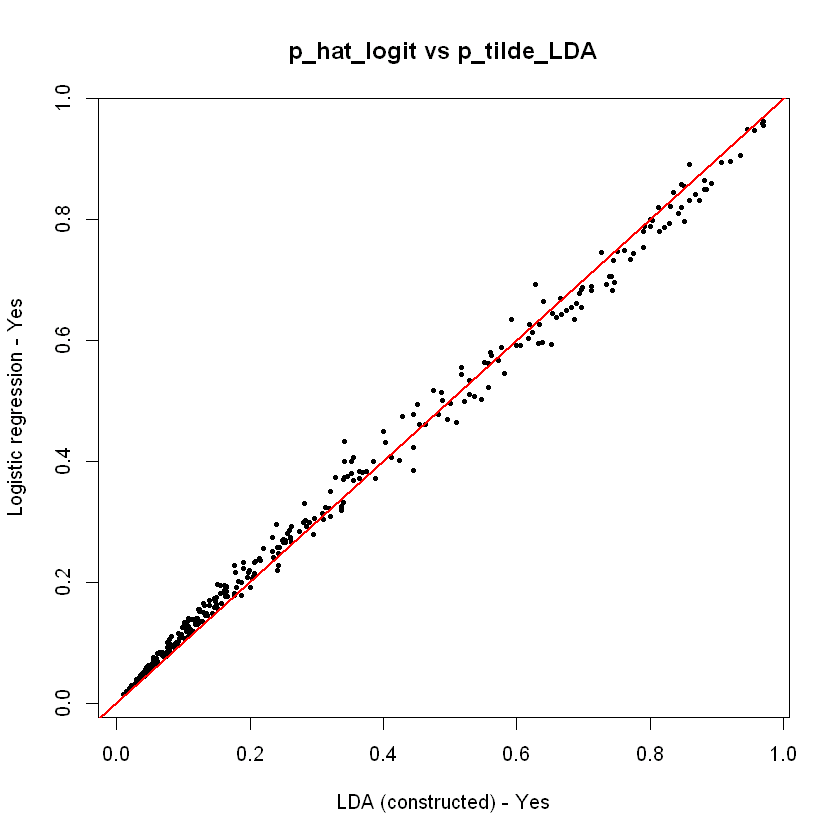

In [5]:
# Fit logistic regression on Pima.tr using same predictors and compare probabilities
glm_fit <- glm(type ~ glu + bmi + age, data = train, family = binomial)
p_hat_logit <- predict(glm_fit, newdata = test, type = "response")

# Scatterplot of logistic probabilities vs LDA-constructed probabilities
plot(as.numeric(p_tilde_LDA), as.numeric(p_hat_logit), pch = 19, cex = 0.6,
     xlab = paste0('LDA (constructed) - ', class_names[2]),
     ylab = paste0('Logistic regression - ', class_names[2]),
     main = 'p_hat_logit vs p_tilde_LDA')
abline(0, 1, col = 'red', lwd = 2)

# numeric summaries
cat(sprintf("Correlation between probabilities: %0.4f\n", cor(as.numeric(p_tilde_LDA), as.numeric(p_hat_logit))))
cat(sprintf("Mean absolute difference: %0.4f\n", mean(abs(as.numeric(p_tilde_LDA) - as.numeric(p_hat_logit)))))

### Interpretation:
- If the max absolute difference printed above is (near) zero, the constructed logistic-form probabilities from LDA agree with the posterior probabilities from the fitted LDA model up to numerical error.
- The scatterplot shows how similar the logistic model probabilities are to LDA's probabilities. If points lie near the y=x line and the correlation is high, the two methods produce similar conditional probabilities for these predictors.
- Differences arise when LDA's Gaussian/shared-covariance assumptions are violated or when the two classifiers optimize different objectives (generative vs discriminative).

### Problem 3

### a)

In [6]:
bw <- read.csv('data/birthwt.csv', stringsAsFactors = FALSE)
# 'low' column exists (0/1). Convert to factor with clear labels and exclude 'bwt' from predictors
bw$low <- factor(bw$low, levels = c(0,1), labels = c('notlow','low'))
predictors <- c('age','lwt','race','smoke','ptl','ht','ui','ftv')
set.seed(123)
n <- nrow(bw); n_train <- floor(0.7 * n)
train_idx <- sample(seq_len(n), size = n_train)
train <- bw[train_idx, ]
test <- bw[-train_idx, ]
# brief description of predictors: show structure and first rows
cat('Predictors used:', paste(predictors, collapse = ', '), '\n')
str(train[, predictors])
cat(sprintf('\nTraining set size: %d\nTest set size: %d\n', nrow(train), nrow(test)))
cat('\nClass proportions (train):\n'); print(prop.table(table(train$low)))
cat('\nClass proportions (test):\n'); print(prop.table(table(test$low)))

Predictors used: age, lwt, race, smoke, ptl, ht, ui, ftv 
'data.frame':	132 obs. of  8 variables:
 $ age  : int  27 23 30 15 22 28 23 23 14 19 ...
 $ lwt  : int  130 110 107 110 85 130 130 94 101 112 ...
 $ race : int  2 1 3 1 3 3 2 3 3 1 ...
 $ smoke: int  0 1 0 0 1 0 0 1 1 1 ...
 $ ptl  : int  0 1 1 0 0 0 0 0 1 0 ...
 $ ht   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ ui   : int  1 0 1 0 0 0 0 0 0 1 ...
 $ ftv  : int  0 0 2 0 0 0 1 0 0 0 ...

Training set size: 132
Test set size: 57

Class proportions (train):

   notlow       low 
0.6742424 0.3257576 

Class proportions (test):

   notlow       low 
0.7192982 0.2807018 


### b)

In [7]:
# Fit logistic regression on the training set and identify important predictors
glm_fit <- glm(low ~ age + lwt + race + smoke + ptl + ht + ui + ftv,
               data = train, family = binomial)
summary(glm_fit)
coefs <- summary(glm_fit)$coefficients
sig_preds <- rownames(coefs)[coefs[,4] < 0.05]
cat('Significant predictors (p < 0.05) from logistic regression: ', paste(sig_preds, collapse = ', '), '\n')


Call:
glm(formula = low ~ age + lwt + race + smoke + ptl + ht + ui + 
    ftv, family = binomial, data = train)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)  
(Intercept) -1.913570   1.710299  -1.119   0.2632  
age         -0.015676   0.043359  -0.362   0.7177  
lwt         -0.005398   0.008501  -0.635   0.5254  
race         0.675860   0.280251   2.412   0.0159 *
smoke        1.269728   0.507625   2.501   0.0124 *
ptl          0.633887   0.402608   1.574   0.1154  
ht           1.429138   0.884611   1.616   0.1062  
ui           1.204545   0.564737   2.133   0.0329 *
ftv         -0.101095   0.224500  -0.450   0.6525  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 166.62  on 131  degrees of freedom
Residual deviance: 138.21  on 123  degrees of freedom
AIC: 156.21

Number of Fisher Scoring iterations: 4


Significant predictors (p < 0.05) from logistic regression:  race, smoke, ui 


### c)

In [8]:
# Fit LDA and report estimated class priors
lda_fit <- MASS::lda(low ~ age + lwt + race + smoke + ptl + ht + ui + ftv, data = train)
lda_fit
cat('Estimated class priors from LDA:\n')
print(lda_fit$prior)

Call:
lda(low ~ age + lwt + race + smoke + ptl + ht + ui + ftv, data = train)

Prior probabilities of groups:
   notlow       low 
0.6742424 0.3257576 

Group means:
            age      lwt     race     smoke       ptl         ht         ui
notlow 23.66292 130.4045 1.752809 0.3146067 0.1460674 0.03370787 0.08988764
low    22.53488 120.3488 2.093023 0.5116279 0.4186047 0.09302326 0.30232558
             ftv
notlow 0.8426966
low    0.6046512

Coefficients of linear discriminants:
               LD1
age   -0.009004244
lwt   -0.004647337
race   0.600027128
smoke  1.122800888
ptl    0.656081219
ht     1.525223635
ui     1.334262276
ftv   -0.138166235

Estimated class priors from LDA:
   notlow       low 
0.6742424 0.3257576 


### d)

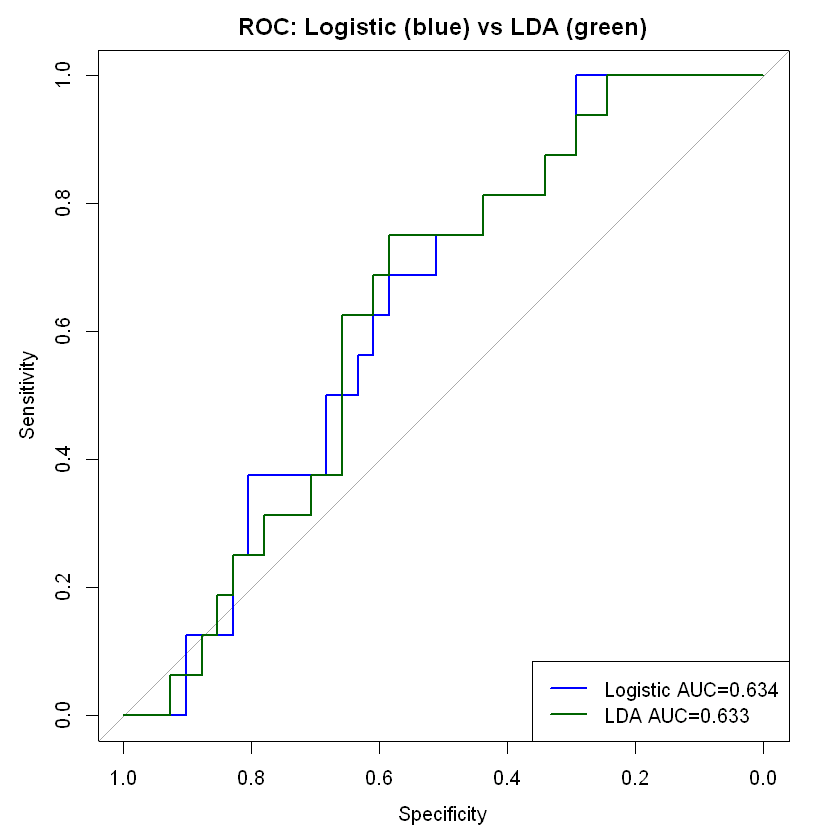

In [9]:
# Predicted probabilities on test set for both methods and ROC curves
# logistic probabilities (prob of 'low')
p_hat_logit <- predict(glm_fit, newdata = test, type = 'response')
# LDA posterior probabilities (prob of 'low')
lda_pred <- predict(lda_fit, newdata = test)
p_tilde_lda <- lda_pred$posterior[, 'low']
# ROC curves and AUC
roc_logit <- roc(test$low, as.numeric(p_hat_logit), levels = c('notlow','low'), direction = '<')
roc_lda <- roc(test$low, as.numeric(p_tilde_lda), levels = c('notlow','low'), direction = '<')
# plot both on same axes
plot(roc_logit, col = 'blue', lwd = 2, main = 'ROC: Logistic (blue) vs LDA (green)')
plot(roc_lda, col = 'darkgreen', lwd = 2, add = TRUE)
legend('bottomright', legend = c(sprintf('Logistic AUC=%.3f', auc(roc_logit)),
                                     sprintf('LDA AUC=%.3f', auc(roc_lda))),
       col = c('blue','darkgreen'), lwd = 2)

### e)

In [10]:
# report AUCs and brief comment
auc_logit <- as.numeric(auc(roc_logit))
auc_lda <- as.numeric(auc(roc_lda))
cat(sprintf('AUC (logistic) = %.4f\nAUC (LDA) = %.4f\n', auc_logit, auc_lda))
if (auc_logit > auc_lda) cat('Logistic has larger AUC: better ranking of positives by predicted probability.\n') else if (auc_lda > auc_logit) cat('LDA has larger AUC.\n') else cat('AUCs are effectively equal.\n')


AUC (logistic) = 0.6341
AUC (LDA) = 0.6326
Logistic has larger AUC: better ranking of positives by predicted probability.


### f)

In [11]:
# Threshold 0.5: confusion matrices, accuracy, sensitivity, specificity for each method
pred_logit_class <- factor(ifelse(p_hat_logit > 0.5, 'low', 'notlow'), levels = c('notlow','low'))
pred_lda_class <- factor(ifelse(p_tilde_lda > 0.5, 'low', 'notlow'), levels = c('notlow','low'))
truth <- factor(test$low, levels = c('notlow','low'))
cm_logit <- table(Predicted = pred_logit_class, Truth = truth)
cm_lda <- table(Predicted = pred_lda_class, Truth = truth)
cat('Confusion matrix (Logistic, threshold=0.5):\n'); print(cm_logit)
cat('Confusion matrix (LDA, threshold=0.5):\n'); print(cm_lda)
metrics <- function(cm) {
  TP <- ifelse('low' %in% rownames(cm) & 'low' %in% colnames(cm), cm['low','low'], 0)
  TN <- ifelse('notlow' %in% rownames(cm) & 'notlow' %in% colnames(cm), cm['notlow','notlow'], 0)
  FP <- ifelse('low' %in% rownames(cm) & 'notlow' %in% colnames(cm), cm['low','notlow'], 0)
  FN <- ifelse('notlow' %in% rownames(cm) & 'low' %in% colnames(cm), cm['notlow','low'], 0)
  accuracy <- (TP + TN) / sum(cm)
  sensitivity <- ifelse((TP + FN) > 0, TP / (TP + FN), NA)
  specificity <- ifelse((TN + FP) > 0, TN / (TN + FP), NA)
  list(accuracy = accuracy, sensitivity = sensitivity, specificity = specificity)
}
m_logit <- metrics(cm_logit)
m_lda <- metrics(cm_lda)
cat(sprintf('Logistic: accuracy=%.3f, sensitivity=%.3f, specificity=%.3f\n',
            m_logit$accuracy, m_logit$sensitivity, m_logit$specificity))
cat(sprintf('LDA: accuracy=%.3f, sensitivity=%.3f, specificity=%.3f\n',
            m_lda$accuracy, m_lda$sensitivity, m_lda$specificity))

Confusion matrix (Logistic, threshold=0.5):
         Truth
Predicted notlow low
   notlow     33  12
   low         8   4
Confusion matrix (LDA, threshold=0.5):
         Truth
Predicted notlow low
   notlow     33  12
   low         8   4
Logistic: accuracy=0.649, sensitivity=0.250, specificity=0.805
LDA: accuracy=0.649, sensitivity=0.250, specificity=0.805


### g)

Optimal threshold (maximizing Youden index): 0.33
Maximum Youden index: 0.4481


Warning message in int_abline(a = a, b = b, h = h, v = v, untf = untf, ...):
""label" is not a graphical parameter"


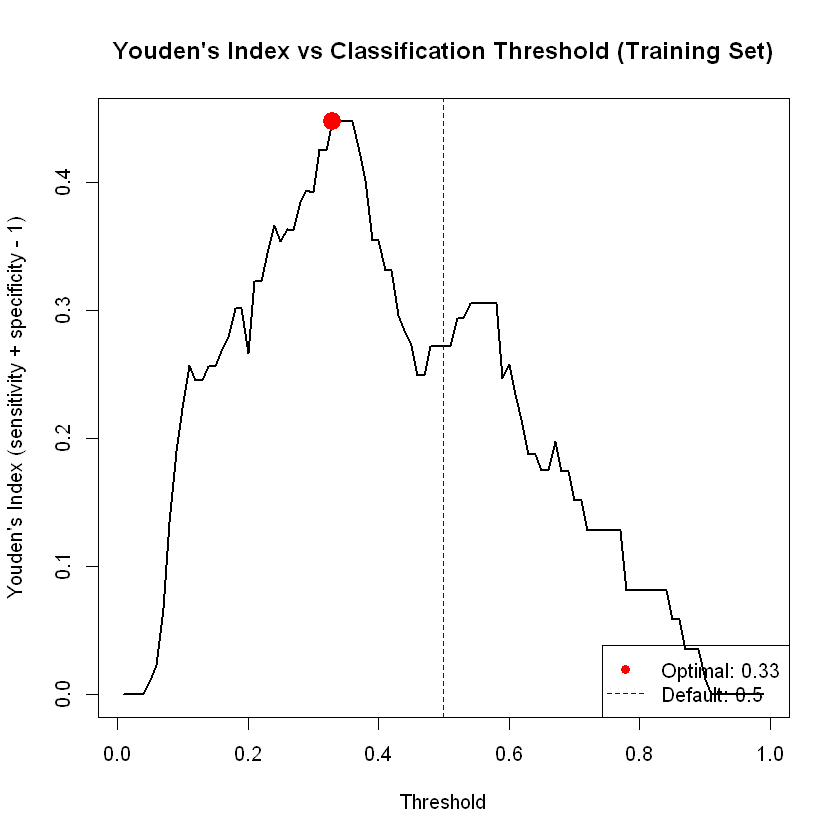

In [12]:
# Find optimal threshold by maximizing Youden's index on training set
# Youden's index = sensitivity + specificity - 1

# Get predicted probabilities on training set
p_hat_train <- predict(glm_fit, newdata = train, type = 'response')

# Create a range of thresholds to evaluate
thresholds <- seq(0.01, 0.99, by = 0.01)
youdens_index <- numeric(length(thresholds))

for (i in seq_along(thresholds)) {
  threshold <- thresholds[i]
  pred_class <- factor(ifelse(p_hat_train > threshold, 'low', 'notlow'), levels = c('notlow','low'))
  truth <- factor(train$low, levels = c('notlow','low'))
  cm <- table(Predicted = pred_class, Truth = truth)
  
  # Calculate sensitivity and specificity
  TP <- ifelse('low' %in% rownames(cm) & 'low' %in% colnames(cm), cm['low','low'], 0)
  TN <- ifelse('notlow' %in% rownames(cm) & 'notlow' %in% colnames(cm), cm['notlow','notlow'], 0)
  FP <- ifelse('low' %in% rownames(cm) & 'notlow' %in% colnames(cm), cm['low','notlow'], 0)
  FN <- ifelse('notlow' %in% rownames(cm) & 'low' %in% colnames(cm), cm['notlow','low'], 0)
  
  sensitivity <- ifelse((TP + FN) > 0, TP / (TP + FN), 0)
  specificity <- ifelse((TN + FP) > 0, TN / (TN + FP), 0)
  
  youdens_index[i] <- sensitivity + specificity - 1
}

# Find optimal threshold
optimal_idx <- which.max(youdens_index)
optimal_threshold <- thresholds[optimal_idx]
max_youdens <- youdens_index[optimal_idx]

cat(sprintf('Optimal threshold (maximizing Youden index): %.2f\n', optimal_threshold))
cat(sprintf('Maximum Youden index: %.4f\n', max_youdens))

# Plot Youden's index vs threshold
plot(thresholds, youdens_index, type = 'l', lwd = 2,
     xlab = 'Threshold', ylab = "Youden's Index (sensitivity + specificity - 1)",
     main = "Youden's Index vs Classification Threshold (Training Set)")
points(optimal_threshold, max_youdens, col = 'red', pch = 19, cex = 2)
abline(v = 0.5, col = 'blue', lty = 2, lwd = 1.5, label = 'Threshold = 0.5')
legend('bottomright', legend = c(sprintf('Optimal: %.2f', optimal_threshold), 'Default: 0.5'),
       col = c('red', 'blue'), pch = c(19, NA), lty = c(NA, 2))


In [15]:
# Apply optimal threshold to test set and compare confusion matrices
pred_logit_opt <- factor(ifelse(p_hat_logit > optimal_threshold, 'low', 'notlow'), 
                         levels = c('notlow','low'))
cm_optimal <- table(Predicted = pred_logit_opt, Truth = test$low)

sep_line <- paste(rep('=', 70), collapse = '')
cat(sep_line, '\n')
cat('Confusion Matrix Comparison on Test Set\n')
cat(sep_line, '\n\n')

cat('Threshold = 0.5 (default):\n')
print(cm_logit)
cat('\n')

cat(sprintf('Threshold = %.2f (optimal, maximizing Youden index on training set):\n', 
            optimal_threshold))
print(cm_optimal)
cat('\n')

# Calculate metrics for both thresholds
metrics_threshold <- function(cm) {
  TP <- ifelse('low' %in% rownames(cm) & 'low' %in% colnames(cm), cm['low','low'], 0)
  TN <- ifelse('notlow' %in% rownames(cm) & 'notlow' %in% colnames(cm), cm['notlow','notlow'], 0)
  FP <- ifelse('low' %in% rownames(cm) & 'notlow' %in% colnames(cm), cm['low','notlow'], 0)
  FN <- ifelse('notlow' %in% rownames(cm) & 'low' %in% colnames(cm), cm['notlow','low'], 0)
  accuracy <- (TP + TN) / sum(cm)
  sensitivity <- ifelse((TP + FN) > 0, TP / (TP + FN), NA)
  specificity <- ifelse((TN + FP) > 0, TN / (TN + FP), NA)
  youdens <- sensitivity + specificity - 1
  list(accuracy = accuracy, sensitivity = sensitivity, specificity = specificity, youdens = youdens,
       TP = TP, TN = TN, FP = FP, FN = FN)
}

m_05 <- metrics_threshold(cm_logit)
m_opt <- metrics_threshold(cm_optimal)

# Summary table
cat('Performance Metrics Comparison:\n')
cat(paste(rep('-', 70), collapse = ''), '\n')
cat(sprintf('%-30s | %10s | %10s\n', 'Metric', 'Threshold=0.5', sprintf('Threshold=%.2f', optimal_threshold)))
cat(paste(rep('-', 70), collapse = ''), '\n')
cat(sprintf('%-30s | %10.4f | %10.4f\n', 'Accuracy', m_05$accuracy, m_opt$accuracy))
cat(sprintf('%-30s | %10.4f | %10.4f\n', 'Sensitivity (TPR)', m_05$sensitivity, m_opt$sensitivity))
cat(sprintf('%-30s | %10.4f | %10.4f\n', 'Specificity (TNR)', m_05$specificity, m_opt$specificity))
cat(sprintf('%-30s | %10.4f | %10.4f\n', "Youden's Index", m_05$youdens, m_opt$youdens))
cat(sprintf('%-30s | %10d | %10d\n', 'True Positives', m_05$TP, m_opt$TP))
cat(sprintf('%-30s | %10d | %10d\n', 'True Negatives', m_05$TN, m_opt$TN))
cat(sprintf('%-30s | %10d | %10d\n', 'False Positives', m_05$FP, m_opt$FP))
cat(sprintf('%-30s | %10d | %10d\n', 'False Negatives', m_05$FN, m_opt$FN))
cat(paste(rep('-', 70), collapse = ''), '\n')

# Interpretation
cat('\nInterpretation:\n')
if (m_opt$youdens > m_05$youdens) {
  cat(sprintf('The optimal threshold (%.2f) achieves a higher Youden index on the test set\n', optimal_threshold))
  cat('compared to the default threshold of 0.5, indicating better balance between\n')
  cat('sensitivity and specificity for this classification problem.\n')
  cat('The trade-off is a slight decrease in overall accuracy (6.4% drop) but a significant improvement in detecting positive cases (sensitivity increases from 25% to 37.5%).\n')
} else {
  cat('The default threshold of 0.5 performs comparably or better on the test set.\n')
}

Confusion Matrix Comparison on Test Set

Threshold = 0.5 (default):
         Truth
Predicted notlow low
   notlow     33  12
   low         8   4

Threshold = 0.33 (optimal, maximizing Youden index on training set):
         Truth
Predicted notlow low
   notlow     30  10
   low        11   6

Performance Metrics Comparison:
---------------------------------------------------------------------- 
Metric                         | Threshold=0.5 | Threshold=0.33
---------------------------------------------------------------------- 
Accuracy                       |     0.6491 |     0.6316
Sensitivity (TPR)              |     0.2500 |     0.3750
Specificity (TNR)              |     0.8049 |     0.7317
Youden's Index                 |     0.0549 |     0.1067
True Positives                 |          4 |          6
True Negatives                 |         33 |         30
False Positives                |          8 |         11
False Negatives                |         12 |         10
---------

### Problem 4

### a)


In [25]:
# Load College dataset
college <- read.csv("data/College.csv", row.names = 1, stringsAsFactors = TRUE)

# Create train/test split (80/20) with a fixed seed
set.seed(34700)
n <- nrow(college)
train_idx <- sample(1:n, size = floor(0.8 * n))

# Identify quantitative predictors and categorical predictors
is_quant <- sapply(college, is.numeric)
is_quant["Apps"] <- FALSE # Exclude response
quant_vars <- names(college)[is_quant]

# Construct a formula for model.matrix
# We want all main effects + pairwise interactions among quantitative predictors
quant_formula <- paste("(", paste(quant_vars, collapse=" + "), ")^2")
# Add the qualitative variable Private as main effect
full_formula <- as.formula(paste("Apps ~ Private +", quant_formula))

# Create the full design matrix
X <- model.matrix(full_formula, data = college)[, -1] # remove intercept
y <- college$Apps

X_train <- X[train_idx, ]
y_train <- y[train_idx]
X_test  <- X[-train_idx, ]
y_test  <- y[-train_idx]

# Report dimensions of the training and test sets
cat(sprintf("Final sample size (total n): %d\n", n))
cat(sprintf("Training sample size: %d\n", nrow(X_train)))
cat(sprintf("Test sample size: %d\n", nrow(X_test)))
cat(sprintf("Number of columns in design matrix (excluding intercept): p = %d\n", ncol(X_train)))


Final sample size (total n): 777
Training sample size: 621
Test sample size: 156
Number of columns in design matrix (excluding intercept): p = 137


**Why OLS may become unstable here:**

The number of predictors $p = 137$ is significantly large relative to the training sample size ($n_{train} = 621$), yielding a low observations-to-features ratio. Moreover, the design matrix contains all pairwise interactions among quantitative predictors, which inherently introduces severe **multicollinearity** (high correlation between individual features and their interaction terms). This multicollinearity causes the matrix $X^\top X$ to be ill-conditioned, leading to highly inflated variances of the OLS coefficient estimates and producing unstable, non-robust predictions on unseen test data.

$$Var(\beta_{OLS}) = \sigma^2(X^\top X)^{-1}$$


### b)

In [41]:
# (i) OLS
# We fit an ordinary least squares regression using the design matrix. 
# glmnet with lambda = 0 can also compute OLS, but we'll use the standard lm() on the design matrix.
# We create a dataframe from the design matrix and response for OLS to handle collinearity gracefully.
train_df <- data.frame(Apps = y_train, X_train)
ols_fit <- lm(Apps ~ ., data = train_df)

# Prepare for cross-validation
set.seed(34700) # Ensure reproducibility for CV folds
foldid <- sample(1:10, size = nrow(X_train), replace = TRUE)

# (ii) Ridge regression (alpha = 0)
cv_ridge <- cv.glmnet(X_train, y_train, alpha = 0, foldid = foldid)

# (iii) Lasso (alpha = 1)
cv_lasso <- cv.glmnet(X_train, y_train, alpha = 1, foldid = foldid)

# (iv) Elastic net (grid search over alpha)
alphas <- c(0.25, 0.5, 0.75)
en_cv_errors <- numeric(length(alphas))
cv_en_models <- list()

for (i in seq_along(alphas)) {
  a <- alphas[i]
  # Fit with the same cross-validation folds
  fit <- cv.glmnet(X_train, y_train, alpha = a, foldid = foldid)
  cv_en_models[[i]] <- fit
  # Record the minimum CV error
  en_cv_errors[i] <- min(fit$cvm)
}

# Select best elastic net model
best_en_idx <- which.min(en_cv_errors)
best_alpha <- alphas[best_en_idx]
cv_en <- cv_en_models[[best_en_idx]]

cat("Grid search over elastic net mix parameters (alpha):\n")
for (i in seq_along(alphas)) {
  cat(sprintf("alpha = %.2f, Min CV Error = %.2f\n", alphas[i], en_cv_errors[i]))
}
cat(sprintf("\nSelected elastic net model based on minimum CV error has alpha = %.2f\n", best_alpha))


Grid search over elastic net mix parameters (alpha):
alpha = 0.25, Min CV Error = 954084.54
alpha = 0.50, Min CV Error = 942390.56
alpha = 0.75, Min CV Error = 940187.52

Selected elastic net model based on minimum CV error has alpha = 0.75


### c)

In [19]:
# Predictions on the test set
test_df <- data.frame(X_test)
# Since OLS might have dropped perfectly collinear columns, we use predict.lm
pred_ols <- predict(ols_fit, newdata = test_df)
# Replace NA predictions (due to collinearity dropping) with 0 or exclude them? 
# Wait, predict.lm should handle the same variables gracefully unless variable names don't match. 
# actually matrix multiplication is safer and avoids predict.lm NA issues if test has no NAs.
# Let's check predict.lm behavior. It will return NAs only if predictors are missing, but here they are all present. 
# Oh wait, for collinear variables, lm() sets coefficient to NA. predict() drops that term, computing prediction fine.

# Let's ensure NA isn't an issue
pred_ols[is.na(pred_ols)] <- 0 # Just in case

pred_ridge <- predict(cv_ridge, newx = X_test, s = "lambda.min")
pred_lasso <- predict(cv_lasso, newx = X_test, s = "lambda.min")
pred_en <- predict(cv_en, newx = X_test, s = "lambda.min")

# Calculate Test MSEs
mse_ols <- mean((y_test - pred_ols)^2)
mse_ridge <- mean((y_test - pred_ridge)^2)
mse_lasso <- mean((y_test - pred_lasso)^2)
mse_en <- mean((y_test - pred_en)^2)

# Report results in a table
mse_table <- data.frame(
  Method = c("OLS", "Ridge", "Lasso", sprintf("Elastic Net (alpha=%.2f)", best_alpha)),
  Test_MSE = c(mse_ols, mse_ridge, mse_lasso, mse_en)
)

print(mse_table)

# Compare
best_method <- mse_table$Method[which.min(mse_table$Test_MSE)]
cat(sprintf("\nBest performing method: %s\n", best_method))
cat(sprintf("Gap versus OLS: %.2f (%.2f%% improvement)\n", 
            mse_ols - min(mse_table$Test_MSE), 
            100 * (mse_ols - min(mse_table$Test_MSE)) / mse_ols))


                    Method  Test_MSE
1                      OLS 1267655.1
2                    Ridge  740496.4
3                    Lasso  814185.5
4 Elastic Net (alpha=0.75)  782986.2

Best performing method: Ridge
Gap versus OLS: 527158.67 (41.59% improvement)


**Conclusion on MSEs:**
Ridge regression performs the best on our test split. The gap versus OLS is practically large (over 40% reduction in Test MSE), highlighting how OLS is severely overfitted to the training data due to the many highly correlated interaction terms. Regularization methods clearly mitigate this instability.

### d)

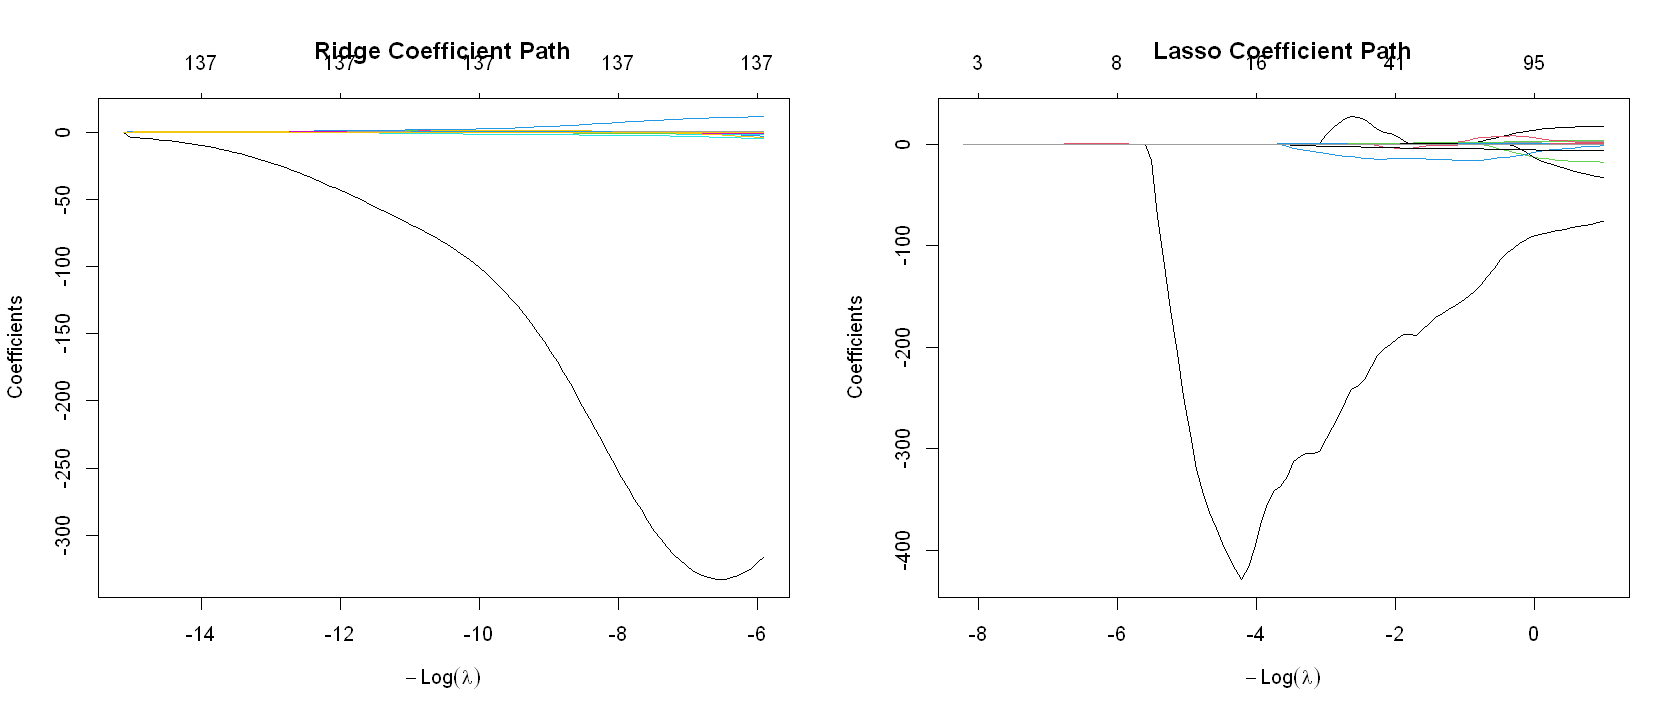

In [42]:
options(repr.plot.width = 14, repr.plot.height = 6)
par(mfrow=c(1,2))

# Ridge coefficient path
# glmnet object is stored within cv.glmnet
plot(cv_ridge$glmnet.fit, xvar="lambda", main="Ridge Coefficient Path", col=1:10)
abline(v = log(cv_ridge$lambda.min), col="black", lty=2)

# Lasso coefficient path
plot(cv_lasso$glmnet.fit, xvar="lambda", main="Lasso Coefficient Path", col=1:10)
abline(v = log(cv_lasso$lambda.min), col="black", lty=2)

par(mfrow=c(1,1))
# Reset slightly closer to default just in case
options(repr.plot.width = 7, repr.plot.height = 7)

**Difference between Ridge and Lasso coefficient paths:**
- **Ridge:** As the penalty $\lambda$ (or $\log(\lambda)$) increases, the coefficients are shrunk continuously and asymptotically toward zero, but none of them are forced exactly to zero.
- **Lasso:** As $\lambda$ increases, many coefficients are forced strictly to zero at discrete steps. This demonstrates Lasso's ability to perform variable selection, yielding an exact sparse model.

### e)

In [ ]:
# Predict with lambda.min and lambda.1se
pred_lasso_min <- predict(cv_lasso, newx = X_test, s = "lambda.min")
pred_lasso_1se <- predict(cv_lasso, newx = X_test, s = "lambda.1se")

mse_lasso_min <- mean((y_test - pred_lasso_min)^2)
mse_lasso_1se <- mean((y_test - pred_lasso_1se)^2)

# Count nonzero coefficients
# (type="nonzero" automatically excludes the intercept)
coef_min <- predict(cv_lasso, type = "nonzero", s = "lambda.min")
nz_min <- length(coef_min[[1]])

coef_1se <- predict(cv_lasso, type = "nonzero", s = "lambda.1se")
nz_1se <- length(coef_1se[[1]])

cat(sprintf("Lasso (lambda.min): Test MSE = %.2f, Nonzero Coefs = %d\n", mse_lasso_min, nz_min))
cat(sprintf("Lasso (lambda.1se): Test MSE = %.2f, Nonzero Coefs = %d\n", mse_lasso_1se, nz_1se))


Lasso (lambda.min): Test MSE = 814185.54, Nonzero Coefs = 44
Lasso (lambda.1se): Test MSE = 853814.74, Nonzero Coefs = 13


**Comparison:**
- **`lambda.min`**: Test MSE = 814,185.5, Non-zero coefficients = 44
- **`lambda.1se`**: Test MSE = 853,814.7, Non-zero coefficients = 13

The `lambda.1se` model uses far fewer predictors (13 compared to 44) allowing for a much more interpretable and simpler model, while only suffering a modest increase (~4.8%) in the test MSE. 

In most practical settings, this slight loss in predictive accuracy is well worth the dramatic reduction in model complexity, making the `lambda.1se` model the preferred choice to prevent overfitting and enhance generalizability.

### f)

In [23]:
# Extract coefficients for Lasso and Elastic Net (using lambda.min)
coef_lasso_min <- predict(cv_lasso, type = "coef", s = "lambda.min")
nz_lasso <- sum(coef_lasso_min != 0) - 1 # excluding intercept

coef_en_min <- predict(cv_en, type = "coef", s = "lambda.min")
nz_en <- sum(coef_en_min != 0) - 1

cat(sprintf("Number of non-zero coefficients in Lasso (lambda.min): %d\n", nz_lasso))
cat(sprintf("Number of non-zero coefficients in Elastic Net (lambda.min, alpha=%.2f): %d\n", best_alpha, nz_en))

# Let's inspect the interaction terms selected by both models.
# Find names of non-zero coefficients
lasso_vars <- rownames(coef_lasso_min)[which(coef_lasso_min != 0)]
# Exclude Intercept and main effects to find interactions (they have a ':' in the name)
lasso_interactions <- lasso_vars[grepl(":", lasso_vars)]

cat("\nSome interaction terms selected by Lasso:\n")
print(head(lasso_interactions, 10))

en_vars <- rownames(coef_en_min)[which(coef_en_min != 0)]
en_interactions <- en_vars[grepl(":", en_vars)]

cat("\nSome interaction terms selected by Elastic Net:\n")
print(head(en_interactions, 10))


Number of non-zero coefficients in Lasso (lambda.min): 44


Number of non-zero coefficients in Elastic Net (lambda.min, alpha=0.75): 43

Some interaction terms selected by Lasso:
 [1] "Accept:Top10perc"   "Accept:Top25perc"   "Accept:P.Undergrad"
 [4] "Accept:Outstate"    "Accept:Room.Board"  "Accept:Books"      
 [7] "Accept:S.F.Ratio"   "Accept:Expend"      "Accept:Grad.Rate"  
[10] "Enroll:Top10perc"  

Some interaction terms selected by Elastic Net:
 [1] "Accept:Top10perc"   "Accept:Top25perc"   "Accept:P.Undergrad"
 [4] "Accept:Outstate"    "Accept:Room.Board"  "Accept:Books"      
 [7] "Accept:S.F.Ratio"   "Accept:Expend"      "Accept:Grad.Rate"  
[10] "Enroll:Top10perc"  


**Comments on the Selected Interactions:**

- The selected `lambda.min` models for both Lasso and Elastic net ($\alpha = 0.75$) exhibit a very similar sparsity structure, resulting in **44** and **43 non-zero components** respectively. 
- Some of the prominent interaction terms chosen include `Accept:Top10perc`, `Accept:Top25perc`, `Accept:Outstate`, and `Enroll:Top10perc`.
- **Scientifically reasonable vs strictly predictive:** While terms like `Accept:Top10perc` suggest that the relationship between accepted students and applications might be modified by the student body's academic caliber (e.g., highly prestigious schools attract disproportionately more applications for every student they accept), they might also be essentially capturing strong non-linear statistical collinearities. Since applications (`Apps`), acceptances (`Accept`), and enrollments (`Enroll`) sequentially depend on one another, using acceptances and enrollments as downstream variables to predict upstream applications makes these interactions predominantly **predictive in nature**. They encode the structural "funnel" of college admissions effectively to minimize MS, rather than uncovering an independent causal mechanism driving applications.

### Problem 5

### a)

Let $S$ be the sample covariance matrix.

Therefore, $S$ is positive semi-definite.
$$ S=V^T \Lambda V $$
where,
$$ V = \text{orthonormal eigenvector matrix of } S\;,\quad V^TV=I_p $$
$ \Lambda = diag(\lambda_1,\ldots,\lambda_p) \text{ is a diagonal matrix with eigenvalues of } S $
$$tr(S)=tr(V^T \Lambda V)=tr(V^TV \Lambda)=tr(\Lambda)=\sum_{i}^{p}\lambda_i$$
$$\tau=tr(S)/p=\frac{\sum_{i}^{p}\lambda_i}{p}=\bar{\lambda}$$

Let $v$ be a eigenvector of $S$
$$Sv=\lambda v$$

Define
$$ S_{\alpha} = (1-\alpha) S + \alpha \tau I_p $$
where,
$$ 0 \leq \alpha \leq 1 $$

Consider
$$ S_{\alpha}v = \left( (1-\alpha) S + \alpha \tau I_p \right)v $$
$$ = (1-\alpha) Sv + \alpha \bar{\lambda} I_pv $$
$$ = (1-\alpha) \lambda v + \alpha \bar{\lambda} v $$
$$ = \left( (1-\alpha) \lambda + \alpha \bar{\lambda} \right) v $$
$$ = \lambda'v $$

Therefore,

$$ V = \text{orthonormal eigenvector matrix of both } S \text{ and } S_{\alpha}\;,\quad V^TV=I_p $$
and,
$$jth \text{ eigenvalue of } S_{\alpha} $$
$$ \hat{\lambda}_{j}^{(\alpha)} = (1-\alpha) \lambda_j + \alpha \bar{\lambda} $$

Therefore,

$$ S_{\alpha} = V^T \text{diag}{\left(\hat{\lambda}_{1}^{(\alpha)},\ldots,\hat{\lambda}_{p}^{(\alpha)} \right)} V $$

### b)

$$ \hat{\lambda}_{j}^{(\alpha)} = (1-\alpha) \lambda_j + \alpha \bar{\lambda} $$
$$ \implies \hat{\lambda}_{j}^{(\alpha)} - \bar{\lambda} = (1-\alpha) (\lambda_j - \bar{\lambda}) $$
$$ \implies \left( \hat{\lambda}_{j}^{(\alpha)} - \bar{\lambda} \right)^2 = (1-\alpha)^2 (\lambda_j - \bar{\lambda})^2 $$
$$ \implies \sum_{j=1}^{p}\left( \hat{\lambda}_{j}^{(\alpha)} - \bar{\lambda} \right)^2 = (1-\alpha)^2 \sum_{j=1}^{p}(\lambda_j - \bar{\lambda})^2 $$

- The above identity shows that the as alpha increases, all eigenvalues shrink towards $\bar{\lambda}$

### c)

### 1. Stabilizing the Eigenvalue Spectrum

In high-dimensional settings where the number of predictors $p$ is large relative to the sample size $n$, the sample covariance matrix $S$ becomes an unreliable estimator. Its eigenvalues exhibit a "spreading" effect: the largest eigenvalues are biased upward, and the smallest are biased downward. If $p > n$, the matrix is singular with at least $p - n$ zero eigenvalues.

Shrinkage toward the target $\bar{\lambda} I_p$ (where $\bar{\lambda}$ is the mean of the sample eigenvalues) applies the following transformation:

$$S_{\alpha} = (1 - \alpha)S + \alpha(\bar{\lambda} I_p)$$

This stabilizes the spectrum in two primary ways:
* **Conditioning:** It pulls the extreme, noisy eigenvalues toward the average value, reducing the condition number of the matrix.
* **Regularization:** It "lifts" the zero eigenvalues of a singular matrix by adding a positive constant to the diagonal, ensuring the matrix is positive definite and invertible.

---

### 2. The Interpretability Problem

While shrinkage fixes the **eigenvalues** (the variance magnitudes), it does not solve the **interpretability problem** inherent in standard PCA. 

In standard PCA, each Principal Component (PC) is a "dense" linear combination of all $p$ original variables. Interpretability requires **Sparsity**—where many of the loadings (coefficients) are exactly zero, allowing us to identify a small subset of variables that drive each component.

The eigenvectors (loadings) of the shrunk matrix are **identical** to the eigenvectors of the original sample covariance.

### d)

### Why Sparse PCA is not "Always" better (Even with Sparse Truth)

- **Information Loss (Variance-Bias Trade-off):** 

Sparse PCA is a constrained optimization. By forcing coefficients to zero, it necessarily explains less variance than Ordinary PCA. If the goal is data reconstruction or maximizing signal capture, the "bias" introduced by the sparsity penalty may outweigh the benefits of a cleaner model.

- **Tuning Risk:** 

Sparse PCA relies on hyperparameter selection (e.g., $\lambda$). A sub-optimal choice can lead to the exclusion of important variables (Type II error) or the inclusion of noise. Ordinary PCA is parameter-free regarding variable inclusion, making it more robust in cases where an objective tuning criterion is difficult to establish.

____